Simulating 2 week paths...

=== SIMULATED AETHER_CRYSTAL PRICE AFTER 2 WEEKS ===
mean:   50.0385
median: 44.1619
min:    3.8500
max:    479.5958
 1%:    13.7748
 5%:    19.3941
10%:    23.2491
25%:    31.5166
50%:    44.1619
75%:    61.8623
90%:    83.7794
95%:    100.5276
99%:    141.8222
Simulating 3 week paths...

=== SIMULATED AETHER_CRYSTAL PRICE AFTER 3 WEEKS ===
mean:   50.0150
median: 41.4598
min:    2.2158
max:    925.6052
 1%:    9.9425
 5%:    15.1485
10%:    18.9280
25%:    27.4443
50%:    41.4598
75%:    62.6546
90%:    90.9185
95%:    113.5478
99%:    172.3479


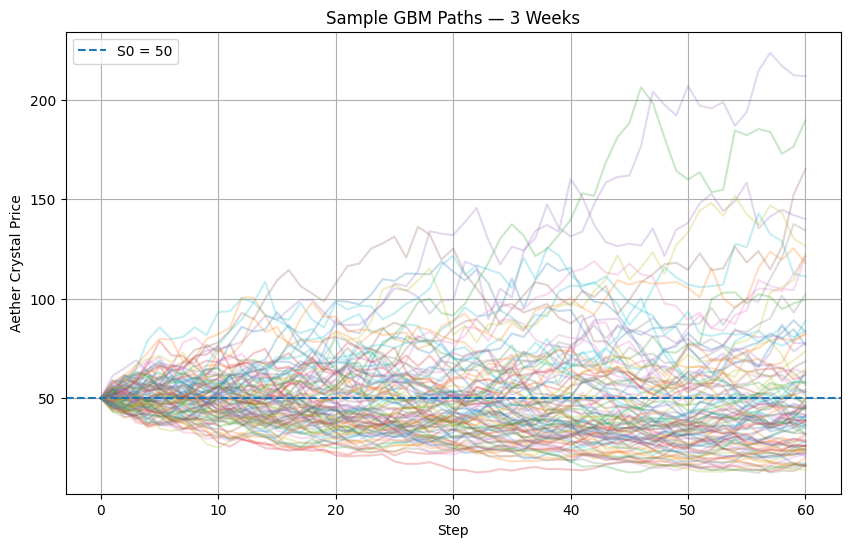

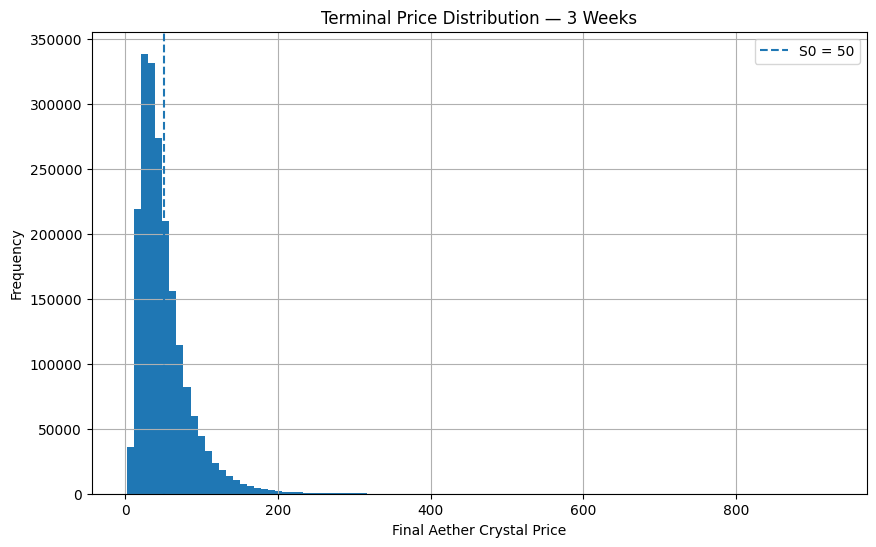

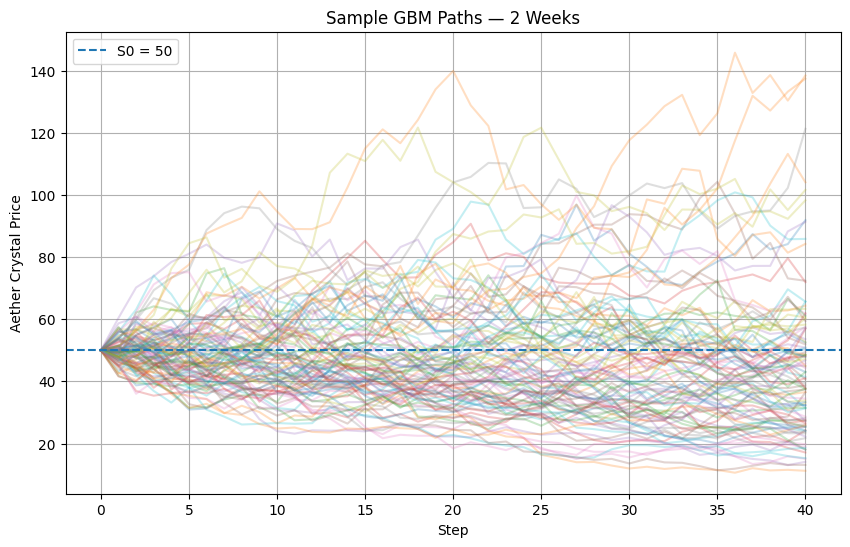

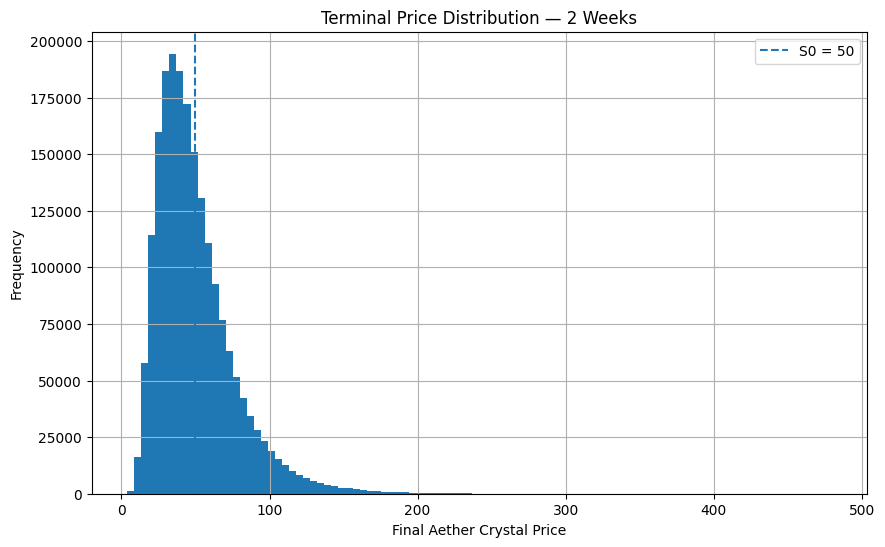


=== FAIR VALUES + TRADING DECISIONS ===

AC              fair= 50.0000  bid= 49.9750  ask= 50.0250  buy_edge= -0.0250  sell_edge= -0.0250  => NO TRADE vol=   0  EV=0.00
AC_50_P         fair= 12.0192  bid= 12.0000  ask= 12.0500  buy_edge= -0.0308  sell_edge= -0.0192  => NO TRADE vol=   0  EV=0.00
AC_50_C         fair= 12.0343  bid= 12.0000  ask= 12.0500  buy_edge= -0.0157  sell_edge= -0.0343  => NO TRADE vol=   0  EV=0.00
AC_35_P         fair=  4.3309  bid=  4.3300  ask=  4.3500  buy_edge= -0.0191  sell_edge= -0.0009  => NO TRADE vol=   0  EV=0.00
AC_40_P         fair=  6.5032  bid=  6.5000  ask=  6.5500  buy_edge= -0.0468  sell_edge= -0.0032  => NO TRADE vol=   0  EV=0.00
AC_45_P         fair=  9.0819  bid=  9.0500  ask=  9.1000  buy_edge= -0.0181  sell_edge= -0.0319  => NO TRADE vol=   0  EV=0.00
AC_60_C         fair=  8.7988  bid=  8.8000  ask=  8.8500  buy_edge= -0.0512  sell_edge=  0.0012  => SELL     vol=  50  EV=174.81
AC_50_P_2       fair=  9.8608  bid=  9.7000  ask=  9.7500  b

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from math import log, sqrt, exp, erf



# =========================
# CONFIG
# =========================

S0 = 50.0
SIGMA = 2.51
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
CONTRACT_SIZE = 3000
N_SIM = 2_000_000
SEED = 42


# =========================
# MARKET TABLE
# Fill bid/ask/size from UI
# bid_size = max volume you can SELL
# ask_size = max volume you can BUY
# =========================

MARKET = [
    # name, type, weeks, strike, extra, bid, ask, bid_size, ask_size

    ("AC", "underlying", 0, None, {}, 49.975, 50.025, 200, 200),

    # T + 21 = 3 weeks
    ("AC_50_P", "put", 3, 50, {}, 12.00, 12.05, 50, 50),
    ("AC_50_C", "call", 3, 50, {}, 12.00, 12.05, 50, 50),
    ("AC_35_P", "put", 3, 35, {}, 4.33, 4.35, 50, 50),
    ("AC_40_P", "put", 3, 40, {}, 6.50, 6.55, 50, 50),
    ("AC_45_P", "put", 3, 45, {}, 9.05, 9.10, 50, 50),
    ("AC_60_C", "call", 3, 60, {}, 8.80, 8.85, 50, 50),

    # T + 14 = 2 weeks
    ("AC_50_P_2", "put", 2, 50, {}, 9.70, 9.75, 50, 50),
    ("AC_50_C_2", "call", 2, 50, {}, 9.70, 9.75, 50, 50),

    # Chooser: choose at T+14, expires T+21
    ("AC_50_CO", "chooser", 3, 50, {}, 22.20, 22.30, 50, 50),

    # Binary put: strike 40, payout 10, expiry T+21
    ("AC_40_BP", "binary_put", 3, 40, {"payout": 10}, 5.00, 5.10, 50, 50),

    # Knock-out put: strike 45, barrier 35, expiry T+21
    ("AC_45_KO", "ko_put", 3, 45, {"barrier": 35}, 0.15, 0.175, 500, 500),
]

def plot_sample_paths(paths, weeks, n_paths=100):
    plt.figure(figsize=(10, 6))

    sample = paths[:n_paths]
    x = np.arange(sample.shape[1])

    for path in sample:
        plt.plot(x, path, alpha=0.25)

    plt.axhline(50, linestyle="--", label="S0 = 50")
    plt.title(f"Sample GBM Paths — {weeks} Weeks")
    plt.xlabel("Step")
    plt.ylabel("Aether Crystal Price")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_terminal_distribution(paths, weeks):
    ST = paths[:, -1]

    plt.figure(figsize=(10, 6))
    plt.hist(ST, bins=100)
    plt.axvline(50, linestyle="--", label="S0 = 50")
    plt.title(f"Terminal Price Distribution — {weeks} Weeks")
    plt.xlabel("Final Aether Crystal Price")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_payoff_distribution(name, payoff):
    plt.figure(figsize=(6, 6))
    plt.hist(payoff, bins=100)
    plt.title(f"Payoff Distribution — {name}")
    plt.xlabel("Payoff")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


# =========================
# TIME HELPERS
# =========================

def weeks_to_years(weeks: float) -> float:
    return (weeks * 5) / TRADING_DAYS_PER_YEAR


def steps_for_weeks(weeks: float) -> int:
    return int(round(weeks * 5 * STEPS_PER_DAY))


# =========================
# GBM SIMULATOR
# =========================

def simulate_gbm(S0, weeks, n=N_SIM, seed=SEED):
    rng = np.random.default_rng(seed)

    steps = steps_for_weeks(weeks)
    T = weeks_to_years(weeks)
    dt = T / steps

    z = rng.normal(size=(n, steps))

    log_returns = (-0.5 * SIGMA**2 * dt) + SIGMA * sqrt(dt) * z
    log_paths = np.cumsum(log_returns, axis=1)

    paths = S0 * np.exp(log_paths)
    paths = np.column_stack([np.full(n, S0), paths])

    return paths

def summarize_terminal_prices(paths, weeks):
    ST = paths[:, -1]

    print(f"\n=== SIMULATED AETHER_CRYSTAL PRICE AFTER {weeks} WEEKS ===")
    print(f"mean:   {ST.mean():.4f}")
    print(f"median: {np.median(ST):.4f}")
    print(f"min:    {ST.min():.4f}")
    print(f"max:    {ST.max():.4f}")

    for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"{q:2d}%:    {np.percentile(ST, q):.4f}")


# =========================
# BLACK-SCHOLES HELPERS
# Used for exact chooser decision at week 2
# =========================

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call(S, K, T, sigma=SIGMA):
    if T <= 0:
        return max(S - K, 0)

    if S <= 0:
        return 0.0

    d1 = (log(S / K) + 0.5 * sigma * sigma * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    return S * norm_cdf(d1) - K * norm_cdf(d2)


def bs_put(S, K, T, sigma=SIGMA):
    if T <= 0:
        return max(K - S, 0)

    if S <= 0:
        return K

    d1 = (log(S / K) + 0.5 * sigma * sigma * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    return K * norm_cdf(-d2) - S * norm_cdf(-d1)


def vector_bs_call(S, K, T):
    S = np.asarray(S)
    out = np.zeros_like(S)

    positive = S > 0
    d1 = np.zeros_like(S)
    d2 = np.zeros_like(S)

    d1[positive] = (np.log(S[positive] / K) + 0.5 * SIGMA**2 * T) / (SIGMA * np.sqrt(T))
    d2[positive] = d1[positive] - SIGMA * np.sqrt(T)

    cdf_d1 = 0.5 * (1.0 + np.vectorize(erf)(d1 / np.sqrt(2.0)))
    cdf_d2 = 0.5 * (1.0 + np.vectorize(erf)(d2 / np.sqrt(2.0)))

    out[positive] = S[positive] * cdf_d1[positive] - K * cdf_d2[positive]
    return out


def vector_bs_put(S, K, T):
    S = np.asarray(S)
    out = np.full_like(S, K)

    positive = S > 0
    d1 = np.zeros_like(S)
    d2 = np.zeros_like(S)

    d1[positive] = (np.log(S[positive] / K) + 0.5 * SIGMA**2 * T) / (SIGMA * np.sqrt(T))
    d2[positive] = d1[positive] - SIGMA * np.sqrt(T)

    cdf_neg_d1 = 0.5 * (1.0 + np.vectorize(erf)(-d1 / np.sqrt(2.0)))
    cdf_neg_d2 = 0.5 * (1.0 + np.vectorize(erf)(-d2 / np.sqrt(2.0)))

    out[positive] = K * cdf_neg_d2[positive] - S[positive] * cdf_neg_d1[positive]
    return out


# =========================
# PAYOFF PRICING
# =========================

def fair_value(name, typ, weeks, K, extra, paths_by_weeks):
    if typ == "underlying":
        # Zero drift, so fair value = S0
        return S0

    paths = paths_by_weeks[weeks]
    ST = paths[:, -1]

    if typ == "call":
        return np.maximum(ST - K, 0).mean()

    if typ == "put":
        return np.maximum(K - ST, 0).mean()

    if typ == "binary_put":
        payout = extra["payout"]
        return (payout * (ST < K)).mean()

    if typ == "ko_put":
        barrier = extra["barrier"]
        knocked_out = np.any(paths <= barrier, axis=1)
        payoff = np.where(knocked_out, 0.0, np.maximum(K - ST, 0)) # np where(Array of Bool, res if True, res if False)
        return payoff.mean()

    if typ == "chooser":
        # Exact-ish chooser:
        # It expires in 3 weeks.
        # At week 2, holder chooses call or put for final week.
        # Value at week 2 = max(1-week call value, 1-week put value).
        choose_step = steps_for_weeks(2)
        S_choose = paths[:, choose_step]

        remaining_T = weeks_to_years(1)

        call_values = vector_bs_call(S_choose, K, remaining_T)
        put_values = vector_bs_put(S_choose, K, remaining_T)

        return np.maximum(call_values, put_values).mean()

    raise ValueError(f"Unknown type: {typ}")


# =========================
# MAIN
# =========================

def main():
    needed_weeks = sorted(set(row[2] for row in MARKET if row[2] > 0))

    # using Geometric Brownian Motion with monte carlo simulation
    paths_by_weeks = {}
    for w in needed_weeks:
        print(f"Simulating {w} week paths...")
        paths_by_weeks[w] = simulate_gbm(S0, w, seed=SEED + int(w * 100))
        summarize_terminal_prices(paths_by_weeks[w], w)


    # =========================
    # VISUALIZER
    # =========================

    if 3 in paths_by_weeks:
        plot_sample_paths(paths_by_weeks[3], weeks=3, n_paths=100)
        plot_terminal_distribution(paths_by_weeks[3], weeks=3)

    if 2 in paths_by_weeks:
        plot_sample_paths(paths_by_weeks[2], weeks=2, n_paths=100)
        plot_terminal_distribution(paths_by_weeks[2], weeks=2)

    print("\n=== FAIR VALUES + TRADING DECISIONS ===\n")

    total_ev = 0.0

    for row in MARKET:
        name, typ, weeks, K, extra, bid, ask, bid_size, ask_size = row

        fair = fair_value(name, typ, weeks, K, extra, paths_by_weeks)

        buy_edge = fair - ask
        sell_edge = bid - fair

        buy_ev = buy_edge * ask_size * CONTRACT_SIZE
        sell_ev = sell_edge * bid_size * CONTRACT_SIZE

        if buy_edge > 0 and buy_ev >= sell_ev:
            action = "BUY"
            volume = ask_size
            trade_price = ask
            ev = buy_ev
        elif sell_edge > 0:
            action = "SELL"
            volume = bid_size
            trade_price = bid
            ev = sell_ev
        else:
            action = "NO TRADE"
            volume = 0
            trade_price = None
            ev = 0.0

        total_ev += ev

        print(f"{name:15s} fair={fair:8.4f}  bid={bid:8.4f}  ask={ask:8.4f}  "
              f"buy_edge={buy_edge:8.4f}  sell_edge={sell_edge:8.4f}  "
              f"=> {action:8s} vol={volume:4d}  EV={ev:,.2f}")


if __name__ == "__main__":
    main()